In [2]:
import xarray as xr
import glob, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import urllib.request
import matplotlib.gridspec as gridspec
from scipy.stats import linregress
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point
from scipy.signal import detrend
import EDJ_PNAS_functions as fedj

In [3]:
### Import ERA5 data

ua_era5 = xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5/ua_ERA5.nc')
ua_era5 = ua_era5.rename({'latitude':'lat','longitude':'lon'})
ua_era5_50 = ua_era5.sel(level=50)
ua_era5_850 = ua_era5.sel(level=850)
ta_era5 = xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5/ta_ERA5.nc')
ta_era5 = ta_era5.rename({'latitude':'lat','longitude':'lon'})

### Import NCEP data

ua_ncep = xr.open_dataset('/home/jmindlin/causal_EDJ/NCEP/uwnd.mon.mean.nc')
ua_ncep_50 = ua_ncep.sel(level=50)
ua_ncep_850 = ua_ncep.sel(level=850)
ta_ncep = xr.open_dataset('/home/jmindlin/causal_EDJ/NCEP/air.mon.mean.nc')

del ua_era5, ua_ncep

# URL of the data file
url = "https://crudata.uea.ac.uk/cru/data/temperature/HadCRUT5.0Analysis_gl.txt"

# Fetch the data from the URL
with urllib.request.urlopen(url) as response:
    lines = response.read().decode('utf-8').splitlines()

# Parse the lines to extract the data
data = []
months = []
years = []
for line in lines[::2]:
    values = line.split(' ')[2:-1]
    years.append(line.split(' ')[1])
    for i, value in enumerate(values):
        if value != '':
            data.append(value)
            months.append(i)

# Convert the list of lists into a NumPy array
data_array = np.array(data, dtype=float)
data_array = data_array[:-12]

# Print the resulting NumPy array
print(data_array)

time = pd.date_range(start='1850-01-01', end='2024-12-01', freq='MS')
temperature_data = xr.DataArray(
    data_array, 
    coords={'time': time}, 
    dims='time', 
    name='temperature - HadCRU5'
)

tas_DJF = fedj.seasonal_data_months(temperature_data.sel(time=slice('1950','2023')),[12,1,2])

u_1979_2019 = xr.open_dataset('/home/jmindlin/causal_EDJ/send_to_LIM/ERA5/ERA5/era5.mon.mean_T42.nc').u.sel(lev=50).drop_vars('lev')
u_1950_1978 = xr.open_dataset('/home/jmindlin/causal_EDJ/send_to_LIM/ERA5/ERA5/ERA5_monthly_u_wind_n36_rename_regrid.nc').u.sel(plev=5000).drop_vars('plev')
u_1950_2019 = xr.concat([u_1950_1978,u_1979_2019],'time')
spv_era5_OND = fedj.seasonal_data_months(u_1950_2019,[10,11,12]).sel(lat=slice(-50,-60)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2019'))
spv_era5_1950_2019_OND = spv_era5_OND
CLIM_spv_era5 = spv_era5_1950_2019_OND.sel(time=slice('1950','2019')).mean(dim='time')

spv_ncep_OND = fedj.seasonal_data_months(ua_ncep_50,[10,11,12]).sel(lat=slice(-50,-60)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2023'))
spv_ncep_1950_2023_OND = spv_ncep_OND
CLIM_spv_ncep = spv_ncep_1950_2023_OND.sel(time=slice('1950','2023')).mean(dim='time')

### Extend ERA5 SPV 2019-2023 with NCEP data
spv_era5_1950_2023_OND = xr.concat([spv_era5_1950_2019_OND,spv_ncep_1950_2023_OND.uwnd.sel(time=slice('2020','2023'))],dim='time')
stratospheric_polar_vortex_rean = []
stratospheric_polar_vortex_rean.append(spv_era5_1950_2023_OND)

tropical_warming = []
tw_era5_DJF = fedj.seasonal_data_months(ta_era5,[12,1,2]).sel(lat=slice(15,-15)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2023'))
tw_era5_1950_2023_DJF = tw_era5_DJF
tropical_warming.append(tw_era5_DJF)
CLIM_tw_ncep = tw_era5_1950_2023_DJF.sel(time=slice('1950','2023')).mean(dim='time')

eesc_ts = pd.read_csv('/home/jmindlin/causal_EDJ/send_to_LIM/GW_EESC_polar_ozoneloss.csv')
for i in range(len(eesc_ts[:8])):
    eesc_ts[i,'EESC_polar'] = eesc_ts['EESC_polar'][8]

eesc_ts_long = eesc_ts - eesc_ts['EESC_polar'][8]


### SST data
sst_ERSST = xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/sst.mnmean_ERSST_2022_KAPLAN_grid.nc') #- xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/sst.mnmean_ERSST_2022_KAPLAN_grid.nc').mean(dim='lon')

sst_ERSST_CP = sst_ERSST.sel(lon=slice(180,250)).sst.sel(lat=slice(-5,5)).mean(dim='lat').mean(dim='lon') 
sst_ERSST_CP_DJF = fedj.seasonal_data_months(sst_ERSST_CP,[12,1,2])
#sst_ERSST_CP_DJF = sst_ERSST_CP_DJF.sel(time=slice('1950','2018'))

sst_ERSST_EP = sst_ERSST.sel(lon=slice(260,280)).sst.sel(lat=slice(0,10)).mean(dim='lat').mean(dim='lon')
sst_ERSST_EP_DJF = fedj.seasonal_data_months(sst_ERSST_EP,[12,1,2])
#sst_ERSST_EP_DJF = sst_ERSST_EP_DJF.sel(time=slice('1950','2018'))

sst_CP_obs = [sst_ERSST_CP_DJF]
sst_EP_obs = [sst_ERSST_EP_DJF]


[-0.675 -0.333 -0.591 ...  1.2    1.225  1.134]


In [4]:

df_sl1 = pd.read_csv('/climca/people/jmindlin/work_folders/EDJ_causal_network/FinalCodes/Notebooks/PublishedFiles/remote_drivers_storylines_meanGW_high.csv')
df_sl2 = pd.read_csv('/climca/people/jmindlin/work_folders/EDJ_causal_network/FinalCodes/Notebooks/PublishedFiles/remote_drivers_storylines_meanGW_low.csv')
era_drivers = pd.read_csv('/climca/people/jmindlin/work_folders/EDJ_causal_network/FinalCodes/Notebooks/PublishedFiles/era5_ersst_drivers.csv')
CMIP6_u850 = xr.open_dataset('/climca/people/jmindlin/work_folders/EDJ_causal_network/FinalCodes/Notebooks/PublishedFiles/CMIP6_model_means_u850.nc')
ua_era5_model_grid = fedj.seasonal_data(xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5/ua_ERA5_model_grid.nc').sel(level=850).u,'DJF')
ua_era5_model_grid_T42 = fedj.seasonal_data(xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5/ua_ERA5_T42.nc').sel(level=850).u,'DJF')
u850_CN_coefs_ERA5_detrend_T42 = xr.open_dataset('/climca/people/jmindlin/work_folders/EDJ_causal_network/FinalCodes/Notebooks/PublishedFiles/regression_coefficients_era5_T42.nc')

ua_era5_djf_clim_T42 = ua_era5_model_grid.sel(time=slice('1950','1979')).mean(dim='time')
ua_era5_djf_std_T42 = ua_era5_model_grid.sel(time=slice('1950','2023')).std(dim='time')

# Time array
time_array = CMIP6_u850.sel(time=slice('1950','2040')).time
ones_array = CMIP6_u850.sel(time=slice('1950','2040')).mean(dim='lat').mean(dim='lon').isel(model=0).ua/CMIP6_u850.sel(time=slice('1950','2040')).mean(dim='lat').mean(dim='lon').isel(model=0).ua
fixed_gw = fedj.make_xarr(df_sl2['gw'][:91], time_array)

# Names of storylines
ta_sources = ["-","+"]
ua50_spv_sources = ["-","+"]
tos_cp_sources = ["-","+"]
tos_ep_sources = ["-","+"]

# Create all combinations (Cartesian product) for the varying components
combinations_names = itertools.product(ta_sources, ua50_spv_sources, tos_cp_sources, tos_ep_sources)

combination_labels = [
    f"TW {comb[0]}, SPV {comb[1]}, CP {comb[2]}, EP {comb[3]}"
    for comb in combinations_names
]

# Define the varying components
ta_sources = [fedj.make_xarr(fedj.std_bias_corr_np(df['ta'][:91],tropical_warming[0].t.sel(time=slice('1950','2023')).values), time_array) for df in [df_sl1, df_sl2]]
ua50_spv_sources = [fedj.make_xarr(fedj.std_bias_corr_np(df['ua50_spv'],stratospheric_polar_vortex_rean[0].sel(time=slice('1950','2023')).values)[:91], time_array) for df in [df_sl1, df_sl2]]
tos_cp_sources = [fedj.make_xarr(fedj.std_bias_corr_np(df['tos_cp'][:91],sst_CP_obs[0].sel(time=slice('1950','2023')).values), time_array) for df in [df_sl1, df_sl2]]
tos_ep_sources = [fedj.make_xarr(fedj.std_bias_corr_np(df['tos_ep'][:91],sst_EP_obs[0].sel(time=slice('1950','2023')).values), time_array) for df in [df_sl1, df_sl2]]


# Create all combinations (Cartesian product) for the varying components
combinations = itertools.product(ta_sources, ua50_spv_sources, tos_cp_sources, tos_ep_sources)


storylines_T42_mem = {}
# Loop through each combination and construct the reconstruction
for i, (ta, ua50_spv, tos_cp, tos_ep) in enumerate(combinations):
    storylines_T42_mem[combination_labels[i]] = (
        ua_era5_djf_clim_T42 * (ones_array) 
        + u850_CN_coefs_ERA5_detrend_T42.tw * ta * ua_era5_djf_std_T42 
        + u850_CN_coefs_ERA5_detrend_T42.spv * ua50_spv * ua_era5_djf_std_T42  
        + u850_CN_coefs_ERA5_detrend_T42.cp * tos_cp * ua_era5_djf_std_T42 
        + u850_CN_coefs_ERA5_detrend_T42.ep * tos_ep * ua_era5_djf_std_T42  
        + u850_CN_coefs_ERA5_detrend_T42.gmst * fixed_gw * ua_era5_djf_std_T42
    )


story_lat_ZM = []; story_str_ZM = []; story_lat_Pa = []; story_str_Pa = []; story_lat_A = []; story_str_A = []
for sl in combination_labels:
        recon_lat_era5_clim, recon_str_era5_clim = fedj.jet_lat_strength_model(storylines_T42_mem[sl],-180,180)
        story_str_ZM.append(fedj.anom_array(recon_str_era5_clim))
        story_lat_ZM.append(fedj.anom_array(recon_lat_era5_clim))
        del recon_lat_era5_clim, recon_str_era5_clim
        recon_lat_era5_clim, recon_str_era5_clim = fedj.jet_lat_strength_model(storylines_T42_mem[sl],-200,-80)
        story_str_Pa.append(fedj.anom_array(recon_str_era5_clim))
        story_lat_Pa.append(fedj.anom_array(recon_lat_era5_clim))
        del recon_lat_era5_clim, recon_str_era5_clim
        recon_lat_era5_clim, recon_str_era5_clim = fedj.jet_lat_strength_model(storylines_T42_mem[sl],-40,140)
        story_str_A.append(fedj.anom_array(recon_str_era5_clim))
        story_lat_A.append(fedj.anom_array(recon_lat_era5_clim))


stories_anom = [story_lat_ZM,story_str_ZM,story_lat_Pa,story_str_Pa,story_lat_A,story_str_A]

In [5]:
# reconstruction with ERA5 patterns - detrended 
ua_era5_djf_clim = ua_era5_model_grid.sel(time=slice('1950','1979')).mean(dim='time')
ua_era5_djf_std = ua_era5_model_grid.sel(time=slice('1950','2023')).std(dim='time')
u850_CN_coefs_ERA5_detrend = xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5_causal_network/anomalies/detrended_data/with_GMST/u850/regression_coefficients_era5_T42.nc')
reconstruction_era5_withGW =  ua_era5_djf_clim*(tas_DJF.sel(time=slice('1950','2023'))/tas_DJF.sel(time=slice('1950','2023'))) + u850_CN_coefs_ERA5_detrend.tw*fedj.std_anom(tropical_warming[0].t.sel(time=slice('1950','2023')))*ua_era5_djf_std + u850_CN_coefs_ERA5_detrend.spv*fedj.std_anom(stratospheric_polar_vortex_rean[0].sel(time=slice('1950','2023')))*ua_era5_djf_std  + u850_CN_coefs_ERA5_detrend.cp*fedj.std_anom(sst_CP_obs[0].sel(time=slice('1950','2023')))*ua_era5_djf_std + u850_CN_coefs_ERA5_detrend.ep*fedj.std_anom(sst_EP_obs[0].sel(time=slice('1950','2023')))*ua_era5_djf_std  + u850_CN_coefs_ERA5_detrend.gmst*fedj.std_anom(tas_DJF.sel(time=slice('1950','2023')))*ua_era5_djf_std
recon_lat_era5, recon_str_era5 = fedj.jet_lat_strength_model(reconstruction_era5_withGW,-180,180)
recon_lat_P_era5, recon_str_P_era5 = fedj.jet_lat_strength_model(reconstruction_era5_withGW,-200,-80)
recon_lat_A_era5, recon_str_A_era5 = fedj.jet_lat_strength_model(reconstruction_era5_withGW,-40,120)
time_obs = tas_DJF.sel(time=slice('1950','2023')).time

In [6]:
# Define the varying components
ta_sources = ["-","+"]
ua50_spv_sources = ["-","+"]
tos_cp_sources = ["-","+"]
tos_ep_sources = ["-","+"]

# Create all combinations (Cartesian product) for the varying components
combinations_names = itertools.product(ta_sources, ua50_spv_sources, tos_cp_sources, tos_ep_sources)

# Labels for subplot ticks
combination_labels = [
    f"TW {comb[0]}, SPV {comb[1]}, CP {comb[2]}, EP {comb[3]}"
    for comb in combinations_names
]

In [7]:
base_dir = '/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/preproc/multiple_regression_indices/ua850'

# Use glob to find all NetCDF files
files = glob.glob(os.path.join(base_dir, "*.nc"))

# Dictionary to store datasets per model
model_datasets = {}

def standardize_time(ds):
    """Convert dataset time coordinates to a standard calendar."""
    if "time" in ds.coords:
        ds["time"] = xr.decode_cf(ds).time  # Decode time while handling different calendars
    return ds

# Process files
for file in files:
    # Extract model and ensemble member from filename
    filename = os.path.basename(file)
    parts = filename.split("_")
    model = parts[1]  # Extract model name (e.g., ACCESS-CM2)
    ensemble = parts[4]  # Extract ensemble member (e.g., r1i1p1f1)
    
    # Open the dataset and standardize time
    ds = xr.open_dataset(file)
    ds = standardize_time(ds)
    
    # Store in dictionary under the model
    if model not in model_datasets:
        model_datasets[model] = []
    model_datasets[model].append(ds)

# List to store mean datasets per model
model_means = []
all_ensemble_members = {}

# Process each model
for model, ds_list in model_datasets.items():
    # Concatenate over a new ensemble dimension
    combined = xr.concat(ds_list, dim="ensemble")
    all_ensemble_members[model] = combined
    
    # Take the mean over the ensemble dimension
    mean_ds = combined.mean(dim="ensemble")
    
    # Add a new coordinate for model
    mean_ds = mean_ds.expand_dims({"model": [model]})
    
    # Store the processed dataset
    model_means.append(mean_ds)


model_means_same_time = []
# Concatenate all models along the model dimension
for model in model_means:
    model['time'] = model_means[0].time
    for i,member in enumerate(all_ensemble_members[str(model.model[0].values)].ensemble):
        all_ensemble_members[str(model.model[0].values)].isel(ensemble=i)['time'] = model_means[0].time
    model_means_same_time.append(model)

# Initialize lists for storing time series of anomalies
lats_ZM, strs_ZM = [], []
lats_Pa, strs_Pa = [], []
lats_At, strs_At = [], []

for m in all_ensemble_members.keys():
    for i, member in enumerate(all_ensemble_members[m].ensemble):
        for region, lon_bounds, lat_list, str_list in [
            ('ZM', (-180, 180), lats_ZM, strs_ZM),
            ('Pa', (-200, -80), lats_Pa, strs_Pa),
            ('At', (-40, 140), lats_At, strs_At)
        ]:
            lat, strength = fedj.jet_lat_strength_model(
                all_ensemble_members[m].isel(ensemble=i).ua.sel(time=slice('1950', '2040')),
                *lon_bounds
            )

            # Compute anomalies (relative to first 30 years)
            lat_anom = lat - np.mean(lat[:30])
            str_anom = strength - np.mean(strength[:30])

            # Save the full anomaly time series
            lat_list.append(lat_anom)
            str_list.append(str_anom)

# Convert to numpy arrays
lats_ZM = np.array(lats_ZM)
strs_ZM = np.array(strs_ZM)
lats_Pa = np.array(lats_Pa)
strs_Pa = np.array(strs_Pa)
lats_At = np.array(lats_At)
strs_At = np.array(strs_At)


In [53]:
base_dir = '/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/preproc/multiple_regression_indices/ua850'

# Use glob to find all NetCDF files
files = glob.glob(os.path.join(base_dir, "*.nc"))

# Dictionary to store datasets per model
model_datasets = {}

def standardize_time(ds):
    """Convert dataset time coordinates to a standard calendar."""
    if "time" in ds.coords:
        ds["time"] = xr.decode_cf(ds).time  # Decode time while handling different calendars
    return ds

# Process files
for file in files:
    # Extract model and ensemble member from filename
    filename = os.path.basename(file)
    parts = filename.split("_")
    model = parts[1]  # Extract model name (e.g., ACCESS-CM2)
    ensemble = parts[4]  # Extract ensemble member (e.g., r1i1p1f1)
    
    # Open the dataset and standardize time
    ds = xr.open_dataset(file)
    ds = standardize_time(ds)
    
    # Store in dictionary under the model
    if model not in model_datasets:
        model_datasets[model] = []
    model_datasets[model].append(ds)

# List to store mean datasets per model
model_means = []
all_ensemble_members = {}

# Process each model
for model, ds_list in model_datasets.items():
    # Concatenate over a new ensemble dimension
    combined = xr.concat(ds_list, dim="ensemble")
    all_ensemble_members[model] = combined
    
    # Take the mean over the ensemble dimension
    mean_ds = combined.mean(dim="ensemble")
    
    # Add a new coordinate for model
    mean_ds = mean_ds.expand_dims({"model": [model]})
    
    # Store the processed dataset
    model_means.append(mean_ds)


model_means_same_time = []
# Concatenate all models along the model dimension
for model in model_means:
    model['time'] = model_means[0].time
    for i,member in enumerate(all_ensemble_members[str(model.model[0].values)].ensemble):
        all_ensemble_members[str(model.model[0].values)].isel(ensemble=i)['time'] = model_means[0].time
    model_means_same_time.append(model)

# Initialize lists for storing time series of anomalies
lats_ZM_model_mean, strs_ZM_model_mean = [], []
lats_Pa_model_mean, strs_Pa_model_mean = [], []
lats_At_model_mean, strs_At_model_mean = [], []

for m in all_ensemble_members.keys():
    for region, lon_bounds, lat_list, str_list in [
        ('ZM', (-180, 180), lats_ZM_model_mean, strs_ZM_model_mean),
        ('Pa', (-200, -80), lats_Pa_model_mean, strs_Pa_model_mean),
        ('At', (-40, 140), lats_At_model_mean, strs_At_model_mean)
    ]:
        lat, strength = fedj.jet_lat_strength_model(
            all_ensemble_members[m].mean(dim='ensemble').ua.sel(time=slice('1950', '2040')),
            *lon_bounds
        )

        # Compute anomalies (relative to first 30 years)
        lat_anom = lat - np.mean(lat[:30])
        str_anom = strength - np.mean(strength[:30])

        # Save the full anomaly time series
        lat_list.append(lat_anom)
        str_list.append(str_anom)

# Convert to numpy arrays
lats_ZM_model_mean = np.array(lats_ZM_model_mean)
strs_ZM_model_mean = np.array(strs_ZM_model_mean)
lats_Pa_model_mean = np.array(lats_Pa_model_mean)
strs_Pa_model_mean = np.array(strs_Pa_model_mean)
lats_At_model_mean = np.array(lats_At_model_mean)
strs_At_model_mean = np.array(strs_At_model_mean)


In [51]:


def plot_mean_with_shading_min_max_lowSL(ax, era5,mean_data,std_data,era5_recon,list_story, time,timeobs,labels_sl):
    """
    Plots the mean value across the 'ensemble' dimension with shading between
    the highest and lowest values for each time step on a given axis.
    
    Parameters:
    - ax: matplotlib.axes.Axes
        The axis to plot on.
    - data: xarray.Dataset
        The dataset containing the variable to plot.
    - variable_name: str
        The name of the variable to plot.
    - title: str
        The title of the subplot.
    """
    # Plot mean values
    handles = []
    a = ax.plot(time,mean_data, label='CMIP6 MEM', color='grey')
    handles.append(a)
    
    # Shade between max and min values
    b = ax.fill_between(time,std_data[0], std_data[1], color='k', alpha=0.1, label='CMIP6 spread ')
    handles.append(b)

    line = ax.plot(timeobs,era5_recon, label='ERA5 CN', alpha=0.7, color='k')
    handles.append(line)


    line = ax.plot(timeobs,era5, label='ERA5', alpha=0.7,color='g')
    handles.append(line)

    line = ax.plot(timeobs,era5*0, label=' ', alpha=0.001, color='k')
    handles.append(line) 

    # Define a custom color palette (8 warm colors, 8 cool colors)
    colors_warm = plt.cm.YlOrRd(np.linspace(0.2, 1, 8))
    colors_cool = plt.cm.PuBu(np.linspace(0.2, 1, 8))
    colors_sl = np.vstack([colors_cool,colors_warm])

    for i,sl in enumerate(list_story):
        if 'SPV -' in labels_sl[i]:
            line = ax.plot(time,sl, label=labels_sl[i], color=colors_sl[i],alpha=0.9)
        else:
            line = ax.plot(time,sl, label=labels_sl[i], color=colors_sl[i],alpha=0.9,linestyle=':')
        handles.append(line)

    # line = ax.plot(time,mean_story, label='mean storyline', color='purple')
    # handles.append(line)
    # Set labels and title
    ax.set_xlabel('Time')
    return ax, handles


def create_figure_with_subplots_min_max_lowSLs(era5, mean_data, std_data,era5_recon, list_story,time, timeobs,labels_sl,y_lim):
    """
    Creates a figure with subplots, each plotting the mean value with shading between
    the highest and lowest values for each time step, and a unified legend below.
    """
    fig, axs = plt.subplots(3, 2, figsize=(12, 8),dpi=300)
    
    # Initialize empty lists to collect handles and labels
    handles = []
    labels = ['CMIP6 MEM','CMIP6 spread','ERA5 CN','ERA5',' ']
    labels.extend(labels_sl)

    # Iterate over subplots
    for i, ax in enumerate(axs.flat):
        ax, subplot_handles = plot_mean_with_shading_min_max_lowSL(
            ax, era5[i][:], mean_data[i], std_data[i], era5_recon[i], list_story[i], time, timeobs, labels_sl
        )
        
        # Flatten subplot_handles and extend the main handles list
        for h in subplot_handles:
            if isinstance(h, list):  # Handle cases where plot returns a list of Line2D objects
                handles.extend(h)
            else:
                handles.append(h)


    subplot_labels = ['a', 'b', 'c', 'd', 'e', 'f']
    y_labels = [
        'Zonal mean \n EDJ latitude [degrees]', 
        'Zonal mean \n EDJ strength [m/s]', 
        'Pacific basin \n EDJ latitude [degrees]', 
        'Pacific basin \n EDJ strength [m/s]',
        'Atlantic-Indian basin \n EDJ latitude [degrees]', 
        'Atlantic-Indian basin \n EDJ strength [m/s]'
    ]

    # Customize each subplot
    for i, ax in enumerate(axs.flat):
        ax.set_ylabel(y_labels[i], fontsize=12)
        if i in [4, 5]:  # Bottom subplots
            ax.set_xlabel('Year', fontsize=12)
        ax.text(0.05, 0.95, subplot_labels[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
        ax.set_ylim(y_lim[i][0],y_lim[i][1])

    # Adjust layout to make space for the legend below the subplots
    fig.subplots_adjust(bottom=0.15)

    # Create a single unified legend below all subplots
    unique_handles, unique_labels = [], []
    for h, l in zip(handles, labels):
        if l not in unique_labels:
            unique_handles.append(h)
            unique_labels.append(l)

    fig.legend(handles=unique_handles, labels=unique_labels, 
               loc='lower center', 
               ncol=5, 
               bbox_to_anchor=(0.5, -0.13))

    plt.tight_layout()
    plt.show()
    return fig


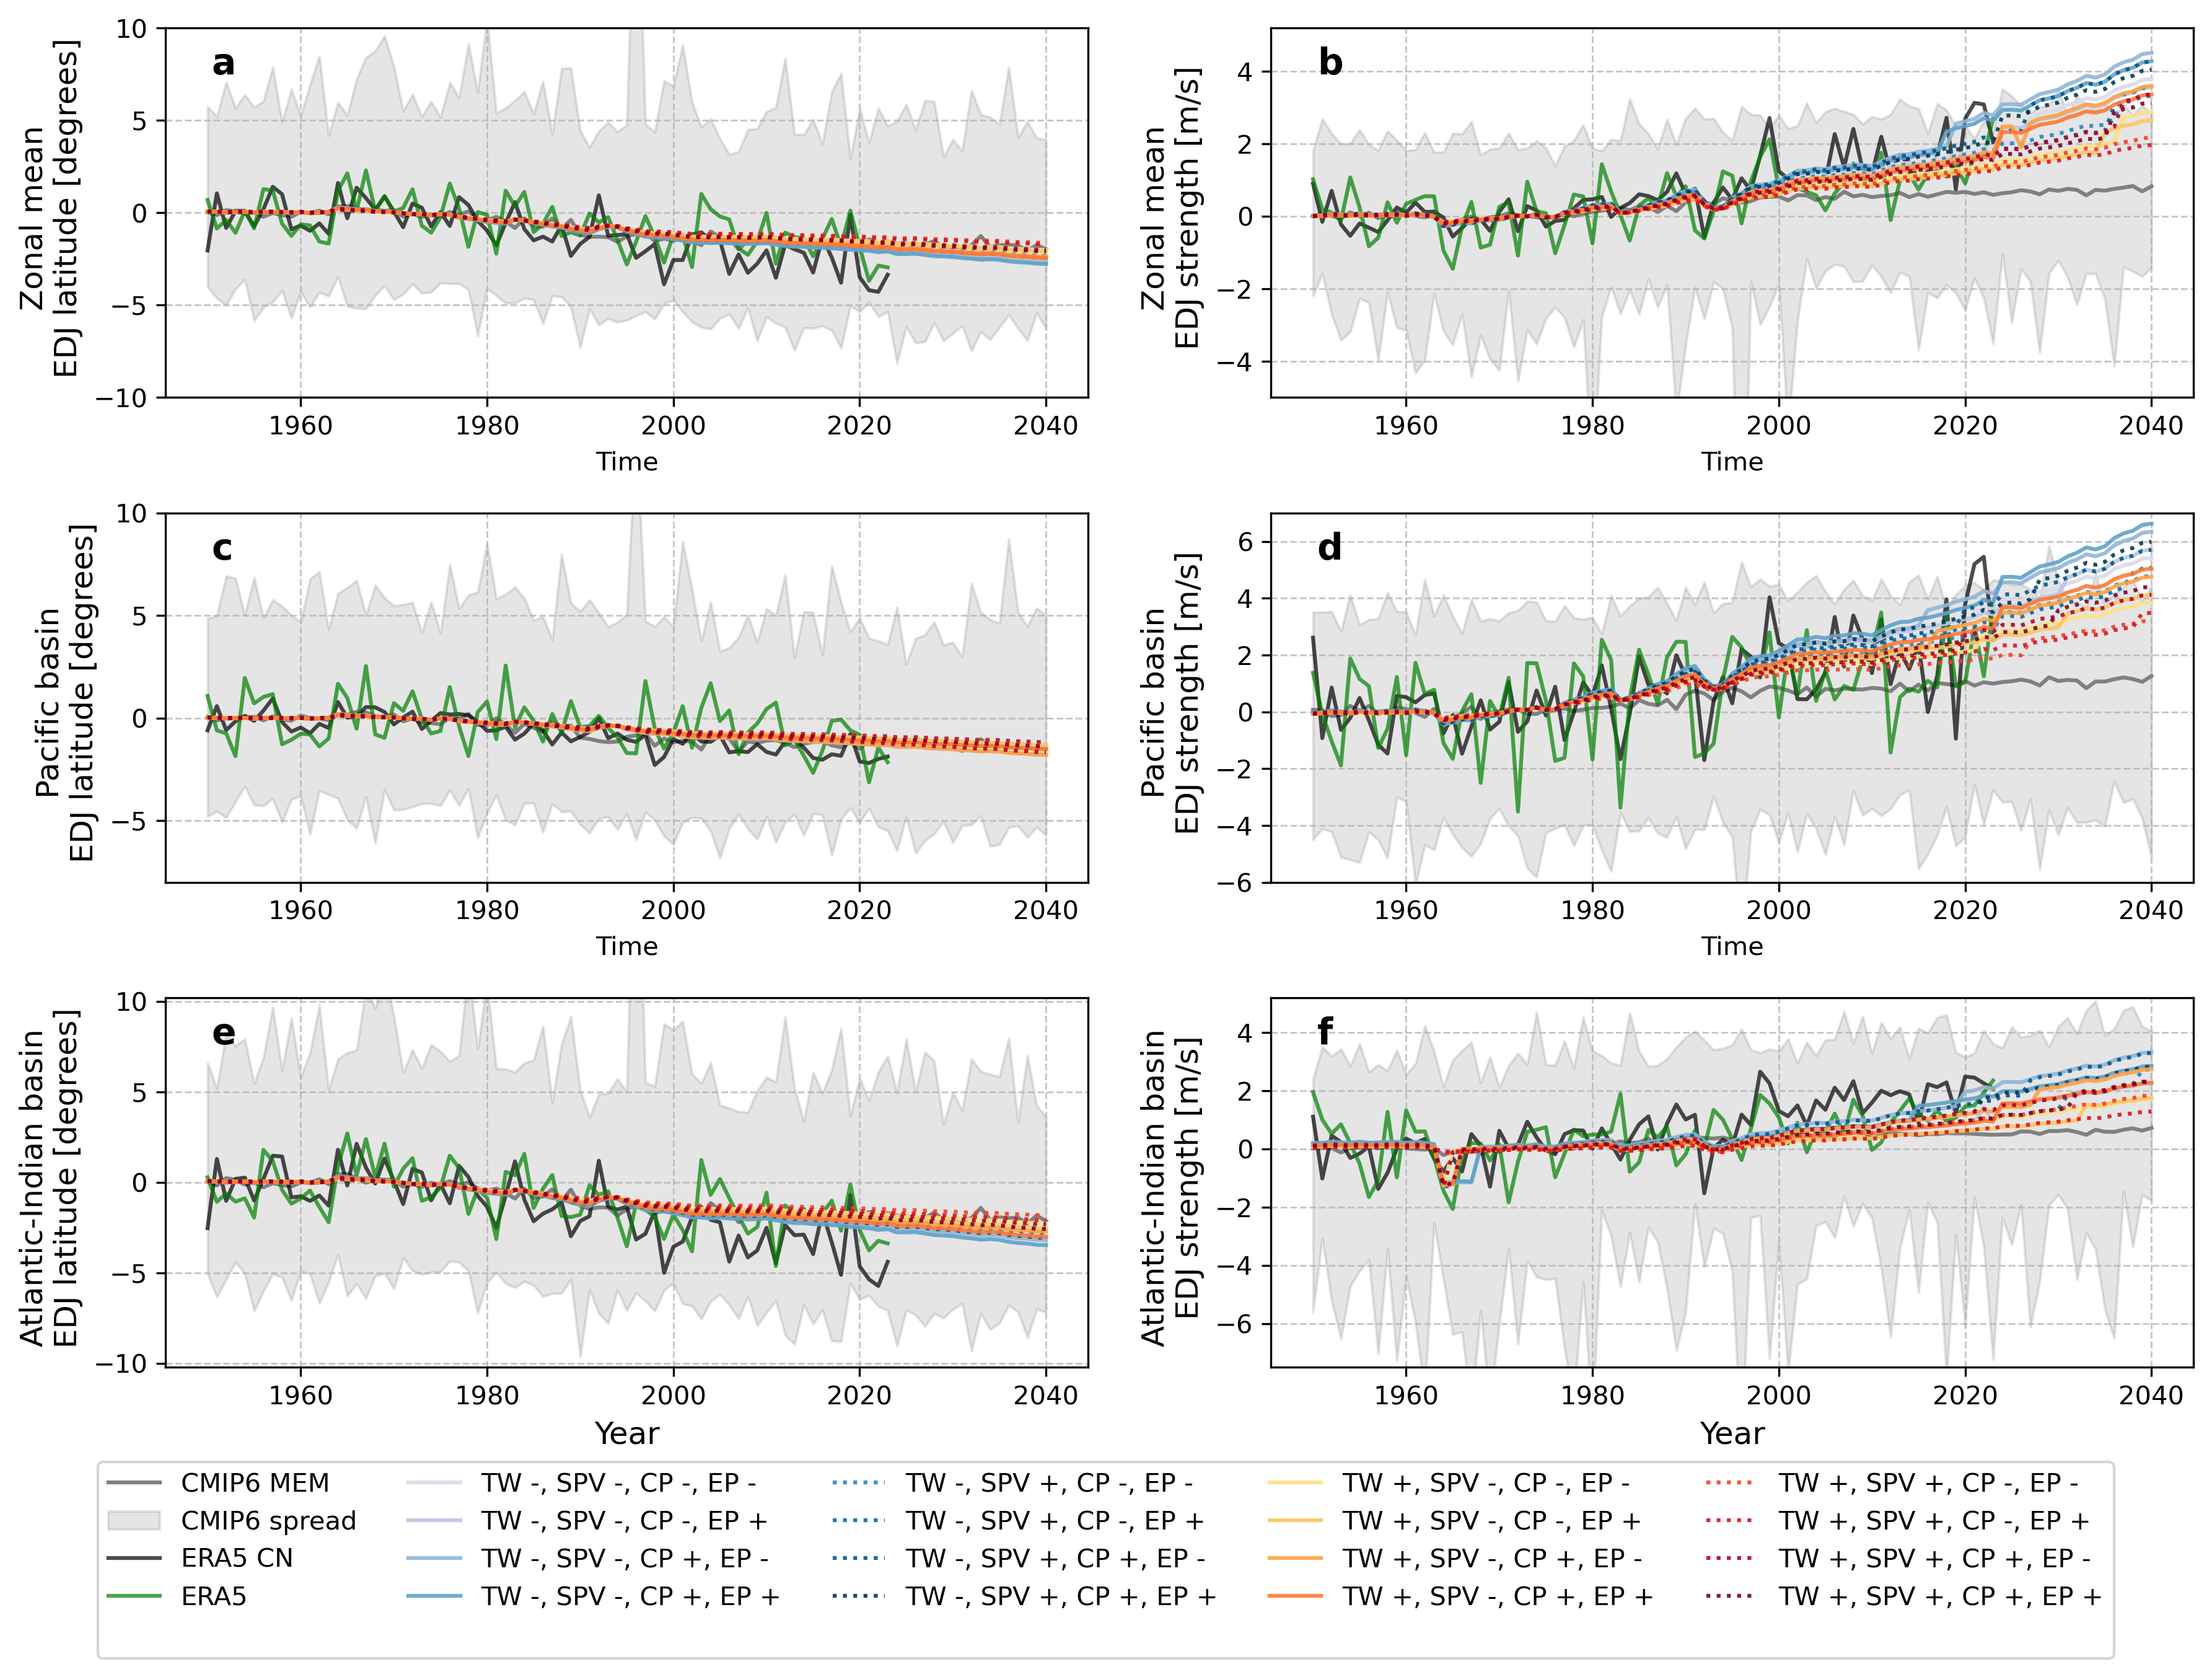

In [52]:
# Assuming the following variables are defined:
# - lats_ZM, strs_ZM, lats_Pa, strs_Pa, lats_At, strs_At
# - story_lat_ZM, story_lat_Pa, story_lat_A
# - story_str_ZM, story_str_Pa, story_str_A
# - era5_lat_ZM, etc. (observed)
# - labels_sl (list of storyline labels)

lat_str_era5 = pd.read_csv("/climca/people/jmindlin/work_folders/EDJ_causal_network/FinalCodes/Notebooks/PublishedFiles/jet_lat_strength_era5.csv")

# Construct required data
data = [lats_ZM, strs_ZM,lats_Pa, strs_Pa,lats_At, strs_At]
story_data = [story_lat_ZM, story_str_ZM, story_lat_Pa, story_str_Pa,story_lat_A,story_str_A]

# Compute anomaly with respect to 1950-1979
era5_data = [lat_str_era5[metric][10:] - np.mean(lat_str_era5[metric][10:40]) for metric in lat_str_era5.keys()]
era5_recon = [recon_lat_era5 , recon_str_era5 , recon_lat_P_era5, recon_str_P_era5 , recon_lat_A_era5, recon_str_A_era5]
era5_recon_anom = [metric - np.mean(metric[:30]) for metric in era5_recon]

# Mean and spread of raw model ensemble (CMIP)
mean_data = [np.mean(d, axis=0) for d in data]
std_data = [[np.min(d, axis=0), np.max(d, axis=0)] for d in data]

# Mean and spread of reconstructed (storyline) ensemble
story_stack = [np.stack(story_data[i], axis=0) for i in range(6)]
mean_data_recon = [np.mean(d, axis=0) for d in story_stack]
std_data_recon = [[np.min(d, axis=0), np.max(d, axis=0)] for d in story_stack]
y_lim = [[-10,10],[-5,5.2],[-8,10],[-6,7],[-10.2,10.2],[-7.5,5.2]]
# Combined storyline list (same format as subplot layout)
list_story = story_stack

# Time arrays
time = np.arange(1950, 2041)  # Full projection
timeobs = np.arange(1950, 2024)  # ERA5 period

# Now use your unified plotting function
fig = create_figure_with_subplots_min_max_lowSLs(
    era5=era5_data,
    mean_data=mean_data,
    std_data=std_data,
    era5_recon=era5_recon_anom,
    list_story=list_story,
    time=time,
    timeobs=timeobs,
    labels_sl=combination_labels,
    y_lim = y_lim
)


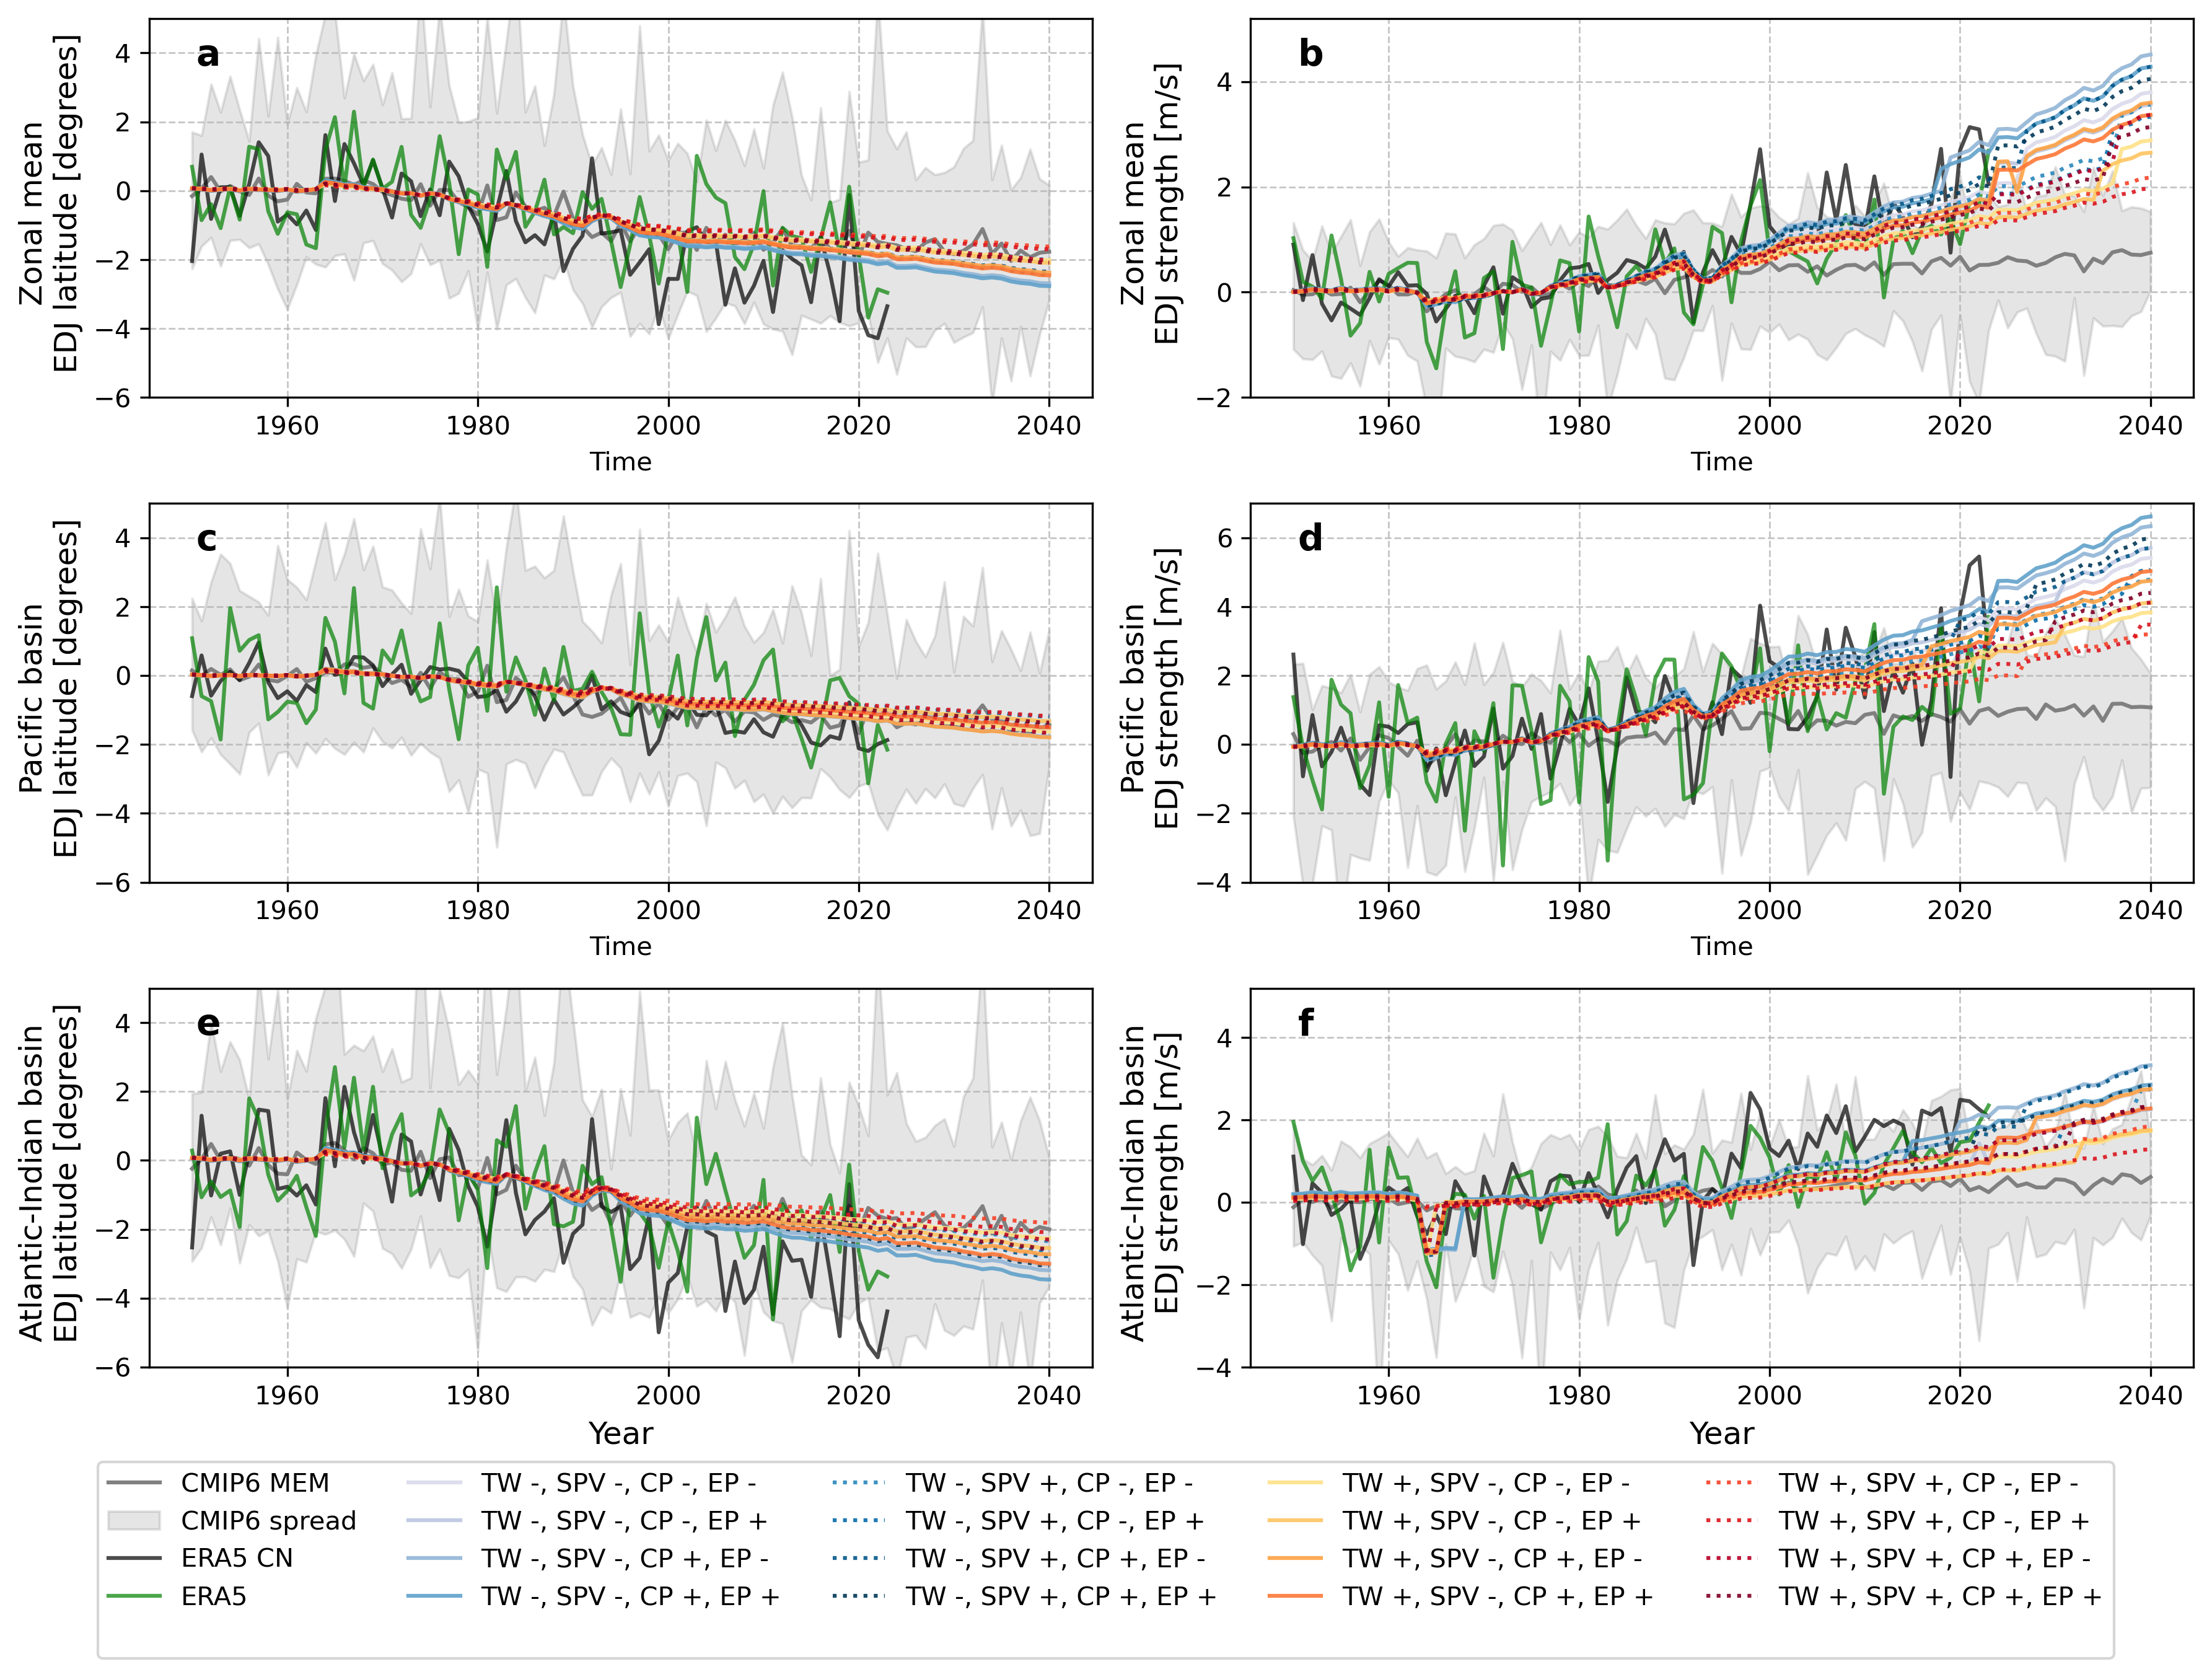

In [56]:
# Assuming the following variables are defined:
# - lats_ZM, strs_ZM, lats_Pa, strs_Pa, lats_At, strs_At
# - story_lat_ZM, story_lat_Pa, story_lat_A
# - story_str_ZM, story_str_Pa, story_str_A
# - era5_lat_ZM, etc. (observed)
# - labels_sl (list of storyline labels)

lat_str_era5 = pd.read_csv("/climca/people/jmindlin/work_folders/EDJ_causal_network/FinalCodes/Notebooks/PublishedFiles/jet_lat_strength_era5.csv")

# Construct required data
data_model_mean = [lats_ZM_model_mean, strs_ZM_model_mean,lats_Pa_model_mean, strs_Pa_model_mean,lats_At_model_mean, strs_At_model_mean]
story_data = [story_lat_ZM, story_str_ZM, story_lat_Pa, story_str_Pa,story_lat_A,story_str_A]

# Compute anomaly with respect to 1950-1979
era5_data = [lat_str_era5[metric][10:] - np.mean(lat_str_era5[metric][10:40]) for metric in lat_str_era5.keys()]
era5_recon = [recon_lat_era5 , recon_str_era5 , recon_lat_P_era5, recon_str_P_era5 , recon_lat_A_era5, recon_str_A_era5]
era5_recon_anom = [metric - np.mean(metric[:30]) for metric in era5_recon]

# Mean and spread of raw model ensemble (CMIP)
mean_data = [np.mean(d, axis=0) for d in data_model_mean]
std_data = [[np.min(d, axis=0), np.max(d, axis=0)] for d in data_model_mean]

# Mean and spread of reconstructed (storyline) ensemble
story_stack = [np.stack(story_data[i], axis=0) for i in range(6)]
mean_data_recon = [np.mean(d, axis=0) for d in story_stack]
std_data_recon = [[np.min(d, axis=0), np.max(d, axis=0)] for d in story_stack]
y_lim = [[-6,5],[-2,5.2],[-6,5],[-4,7],[-6,5],[-4,5.2]]
# Combined storyline list (same format as subplot layout)
list_story = story_stack

# Time arrays
time = np.arange(1950, 2041)  # Full projection
timeobs = np.arange(1950, 2024)  # ERA5 period

# Now use your unified plotting function
fig = create_figure_with_subplots_min_max_lowSLs(
    era5=era5_data,
    mean_data=mean_data,
    std_data=std_data,
    era5_recon=era5_recon_anom,
    list_story=list_story,
    time=time,
    timeobs=timeobs,
    labels_sl=combination_labels,
    y_lim = y_lim
)


In [13]:
# Create Bayes factor lists
BF_lists = [[] for _ in range(6)]  # One list per subplot (lat/str in ZM, Pa, At)

for i in range(6):
    for recon in list_story[i]:
        BF = fedj.bayes_factor_RD(
            era5_recon_anom[i],  # Reference: anomaly of ERA5 recon
            recon[:74],               # Storyline reconstruction
            mean_data[i][:74]         # Raw ensemble mean (CMIP)
        )
        BF_lists[i].append(BF)


In [47]:
# Create custom legend (assuming each unique color represents a storyline)
from matplotlib.lines import Line2D

def plot_bayes_factor_panels(BF_lists, colors, subplot_labels_scatter):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=300)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        ax.set_yscale('log')
        ax.scatter(
            np.arange(len(BF_lists[i])),
            BF_lists[i],
            c=colors[:len(BF_lists[i])],
            s=50, edgecolors='black', alpha=0.8
        )
        ax.set_xlim(-0.5, len(BF_lists[i]) - 0.5)
        ax.set_ylim(1e-6, 1e10)
        ax.axhline(y=1, color='black', linestyle='--', linewidth=1)
        ax.axhspan(0.1, 10, color='k', alpha=0.2)
        ax.grid(True, which='both', linestyle='--', alpha=0.7)
        ax.text(0.03, 0.97, subplot_labels_scatter[i], transform=ax.transAxes, 
                fontsize=14, fontweight='bold', va='top', ha='left')
        ax.set_xticks([])

        # Add domain titles only on top row
        if i < 3:
            domain = ['Zonal Mean \n log(P(ERA5|SL)/P(ERA5|MEM))', 'Pacific \n log(P(ERA5|SL)/P(ERA5|MEM))', 'Atlantic-Indian \n log(P(ERA5|SL)/P(ERA5|MEM))'][i]
            ax.set_title(domain, fontsize=12, pad=12)

    # Add side labels for Latitude and Strength rows
    fig.text(0.04, 0.77, 'EDJ Latitude', fontsize=12, rotation='vertical', va='center')
    fig.text(0.04, 0.28, 'EDJ Strength', fontsize=12,rotation='vertical', va='center')

    fig.legend(loc='lower center', 
               ncol=5, 
               bbox_to_anchor=(0.5, -0.15))
    
    # Example labels corresponding to the colors used
    labels_sl = combination_labels

    # Build legend entries
    unique_colors = [tuple(c) for c in colors]  # Deduplicate colors
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=col, 
                            markeredgecolor='black', markersize=8, label=label)
                    for col, label in zip(unique_colors, labels_sl[:len(unique_colors)])]

    # Add legend
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.15))

    plt.tight_layout(rect=[0.05, 0, 1, 1])  # Leave space for side labels
    plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


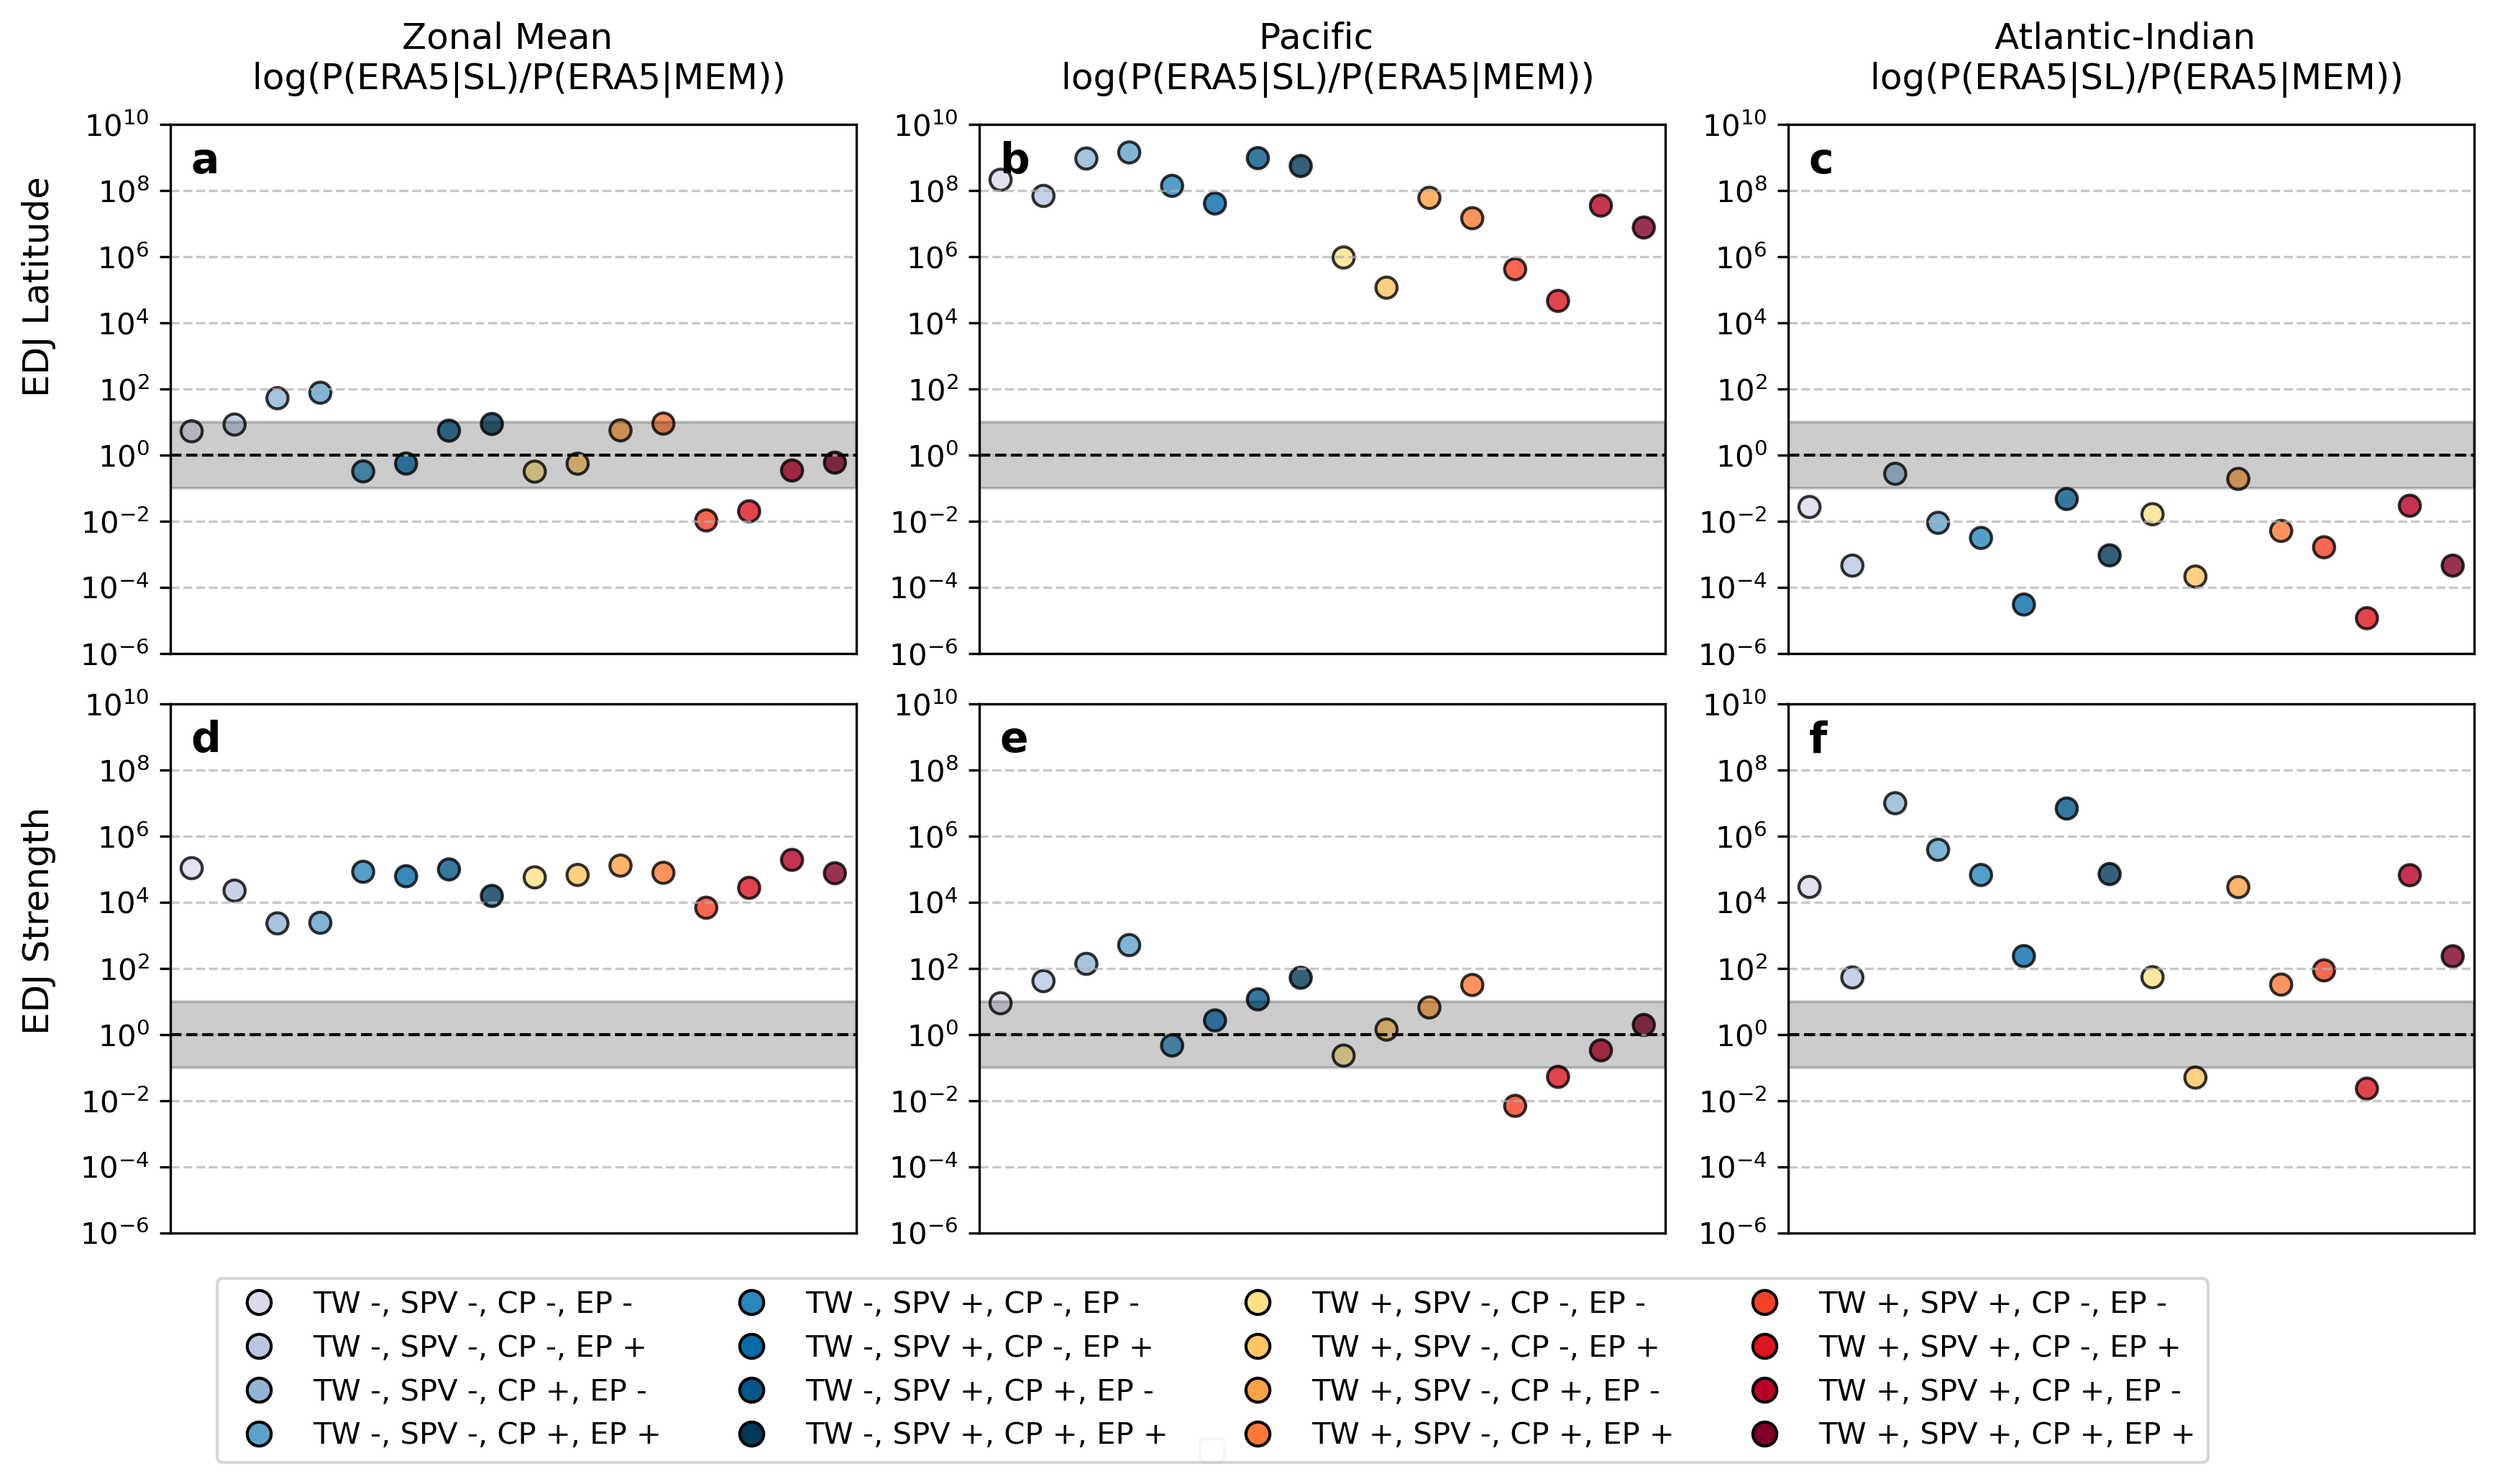

In [48]:
# Define a custom color palette (8 warm colors, 8 cool colors)
colors_warm = plt.cm.YlOrRd(np.linspace(0.2, 1, 8))
colors_cool = plt.cm.PuBu(np.linspace(0.2, 1, 8))
colors = np.vstack([colors_cool,colors_warm])
subplots_labels_scatter = ['a', 'b', 'c', 'd', 'e', 'f']
plot_bayes_factor_panels(BF_lists, colors, subplots_labels_scatter)